# Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# EDA

## Data Loading

In [2]:
red_url = "https://raw.githubusercontent.com/AzrilFahmiardi/wine-quality-pbl/refs/heads/main/data/winequality-red.csv"
white_url = "https://raw.githubusercontent.com/AzrilFahmiardi/wine-quality-pbl/refs/heads/main/data/winequality-white.csv"


df_red = pd.read_csv(red_url, sep=';')
df_red['type'] = 'Red'
df_white = pd.read_csv(white_url, sep=';')
df_white['type'] = 'White'

df = pd.concat([df_red, df_white], ignore_index=True)

print(f'Dataset red wine: {df_red.shape}')
print(f'Dataset white wine: {df_white.shape}')
print(f'Dataset gabungan: {df.shape}')

Dataset red wine: (1599, 13)
Dataset white wine: (4898, 13)
Dataset gabungan: (6497, 13)


## Exploratory Overview

### Informasi Umum Dataset

In [4]:
df

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,type
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5,Red
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.99680,3.20,0.68,9.8,5,Red
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.99700,3.26,0.65,9.8,5,Red
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.99800,3.16,0.58,9.8,6,Red
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5,Red
...,...,...,...,...,...,...,...,...,...,...,...,...,...
6492,6.2,0.21,0.29,1.6,0.039,24.0,92.0,0.99114,3.27,0.50,11.2,6,White
6493,6.6,0.32,0.36,8.0,0.047,57.0,168.0,0.99490,3.15,0.46,9.6,5,White
6494,6.5,0.24,0.19,1.2,0.041,30.0,111.0,0.99254,2.99,0.46,9.4,6,White
6495,5.5,0.29,0.30,1.1,0.022,20.0,110.0,0.98869,3.34,0.38,12.8,7,White


In [3]:
print('Dataset Shape:', df.shape)
print('\n' + '='*50)
print('Data Types')
print('='*50)
print(df.dtypes)
print('\n' + '='*50)
print('Memory Usage')
print('='*50)
print(df.memory_usage(deep=True))
print(f'\nTotal Memory: {df.memory_usage(deep=True).sum() / 1024:.2f} KB')

Dataset Shape: (6497, 13)

Data Types
fixed acidity           float64
volatile acidity        float64
citric acid             float64
residual sugar          float64
chlorides               float64
free sulfur dioxide     float64
total sulfur dioxide    float64
density                 float64
pH                      float64
sulphates               float64
alcohol                 float64
quality                   int64
type                     object
dtype: object

Memory Usage
Index                      132
fixed acidity            51976
volatile acidity         51976
citric acid              51976
residual sugar           51976
chlorides                51976
free sulfur dioxide      51976
total sulfur dioxide     51976
density                  51976
pH                       51976
sulphates                51976
alcohol                  51976
quality                  51976
type                    347640
dtype: int64

Total Memory: 948.71 KB


### Statistik Deskriptif
Statistik dasar meliputi mean, standar deviasi, minimum, maksimum, dan quartile untuk semua fitur numerik.

In [ ]:
df.describe().round(3)

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,6497.000,6497.000,6497.000,6497.000,6497.000,6497.000,6497.000,6497.000,6497.000,6497.000,6497.000,6497.000
mean,7.215,0.340,0.319,5.443,0.056,30.525,115.745,0.995,3.219,0.531,10.492,5.818
std,1.296,0.165,0.145,4.758,0.035,17.749,56.522,0.003,0.161,0.149,1.193,0.873
min,3.800,0.080,0.000,0.600,0.009,1.000,6.000,0.987,2.720,0.220,8.000,3.000
25%,6.400,0.230,0.250,1.800,0.038,17.000,77.000,0.992,3.110,0.430,9.500,5.000
50%,7.000,0.290,0.310,3.000,0.047,29.000,118.000,0.995,3.210,0.510,10.300,6.000
75%,7.700,0.400,0.390,8.100,0.065,41.000,156.000,0.997,3.320,0.600,11.300,6.000
max,15.900,1.580,1.660,65.800,0.611,289.000,440.000,1.039,4.010,2.000,14.900,9.000


## Data Quality Assessment

### Analisis Nilai Kosong dan Duplikat

In [5]:
print('Missing Values')
print('='*50)
missing = df.isnull().sum()
print(missing[missing > 0] if missing.sum() > 0 else 'Tidak ada missing values')


duplicates = df.duplicated().sum()
print(f'\nDuplicate Rows: {duplicates}')
print(f'\nDataset Info:')
print(f'Total Rows: {len(df)}')
print(f'Total Columns: {len(df.columns)}')
print(f'Unique Rows: {len(df.drop_duplicates())}')

Missing Values
Tidak ada missing values

Duplicate Rows: 1177

Dataset Info:
Total Rows: 6497
Total Columns: 13
Unique Rows: 5320


## Feature Distributions

### Distribusi Target Variable (Quality)

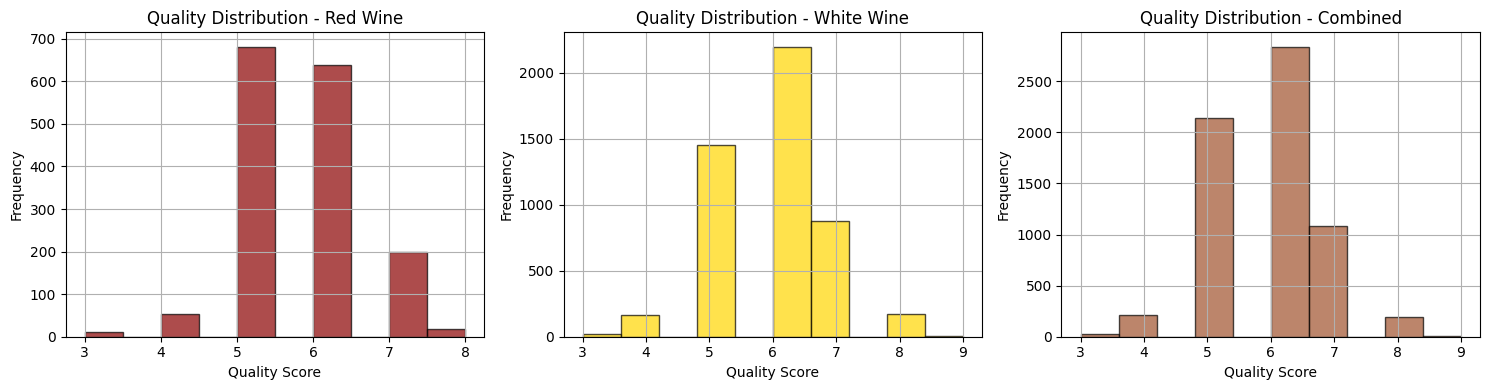

Quality Distribution Statistics
Red Wine Quality Stats:
count    1599.000000
mean        5.636023
std         0.807569
min         3.000000
25%         5.000000
50%         6.000000
75%         6.000000
max         8.000000
Name: quality, dtype: float64

White Wine Quality Stats:
count    4898.000000
mean        5.877909
std         0.885639
min         3.000000
25%         5.000000
50%         6.000000
75%         6.000000
max         9.000000
Name: quality, dtype: float64

Combined Quality Stats:
count    6497.000000
mean        5.818378
std         0.873255
min         3.000000
25%         5.000000
50%         6.000000
75%         6.000000
max         9.000000
Name: quality, dtype: float64


In [6]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

df[df['type'] == 'Red']['quality'].hist(bins=10, ax=axes[0], color='#8B0000', alpha=0.7, edgecolor='black')
axes[0].set_title('Quality Distribution - Red Wine')
axes[0].set_xlabel('Quality Score')
axes[0].set_ylabel('Frequency')

df[df['type'] == 'White']['quality'].hist(bins=10, ax=axes[1], color='#FFD700', alpha=0.7, edgecolor='black')
axes[1].set_title('Quality Distribution - White Wine')
axes[1].set_xlabel('Quality Score')
axes[1].set_ylabel('Frequency')

df['quality'].hist(bins=10, ax=axes[2], color='#A0522D', alpha=0.7, edgecolor='black')
axes[2].set_title('Quality Distribution - Combined')
axes[2].set_xlabel('Quality Score')
axes[2].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

print('Quality Distribution Statistics')
print('='*50)
print(f'Red Wine Quality Stats:\n{df[df["type"] == "Red"]["quality"].describe()}')
print(f'\nWhite Wine Quality Stats:\n{df[df["type"] == "White"]["quality"].describe()}')
print(f'\nCombined Quality Stats:\n{df["quality"].describe()}')

### Distribusi Fitur Fisikokimia
Visualisasi distribusi dari 11 fitur masukan yang merepresentasikan sifat fisikokimia wine. Fitur-fitur ini adalah: fixed acidity, volatile acidity, citric acid, residual sugar, chlorides, free sulfur dioxide, total sulfur dioxide, density, pH, sulphates, dan alcohol.

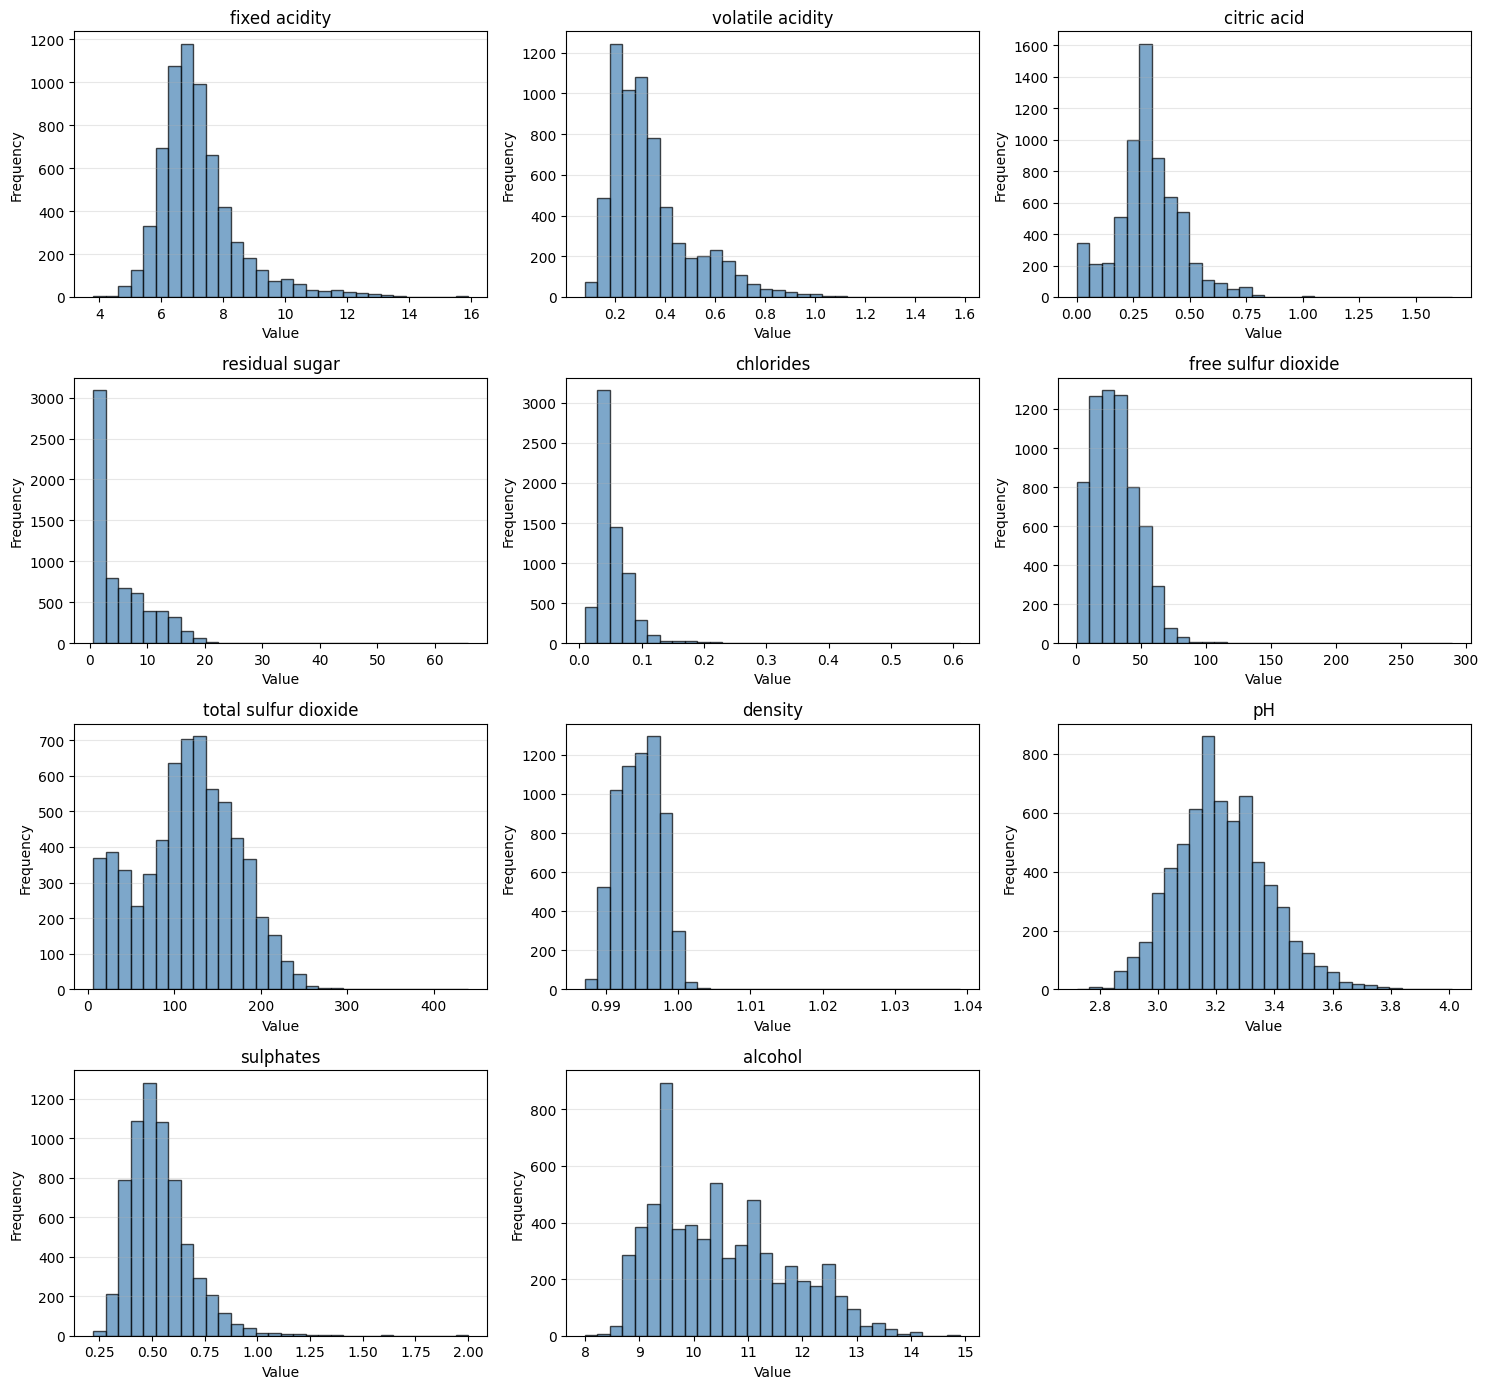

In [7]:
features = [col for col in df.columns if col not in ['quality', 'type']]

fig, axes = plt.subplots(4, 3, figsize=(15, 14))
axes = axes.ravel()

for idx, feature in enumerate(features):
    axes[idx].hist(df[feature], bins=30, color='steelblue', alpha=0.7, edgecolor='black')
    axes[idx].set_title(f'{feature}')
    axes[idx].set_xlabel('Value')
    axes[idx].set_ylabel('Frequency')
    axes[idx].grid(axis='y', alpha=0.3)

axes[-1].remove()
plt.tight_layout()
plt.show()

### Perbandingan Distribusi Antar Tipe Wine

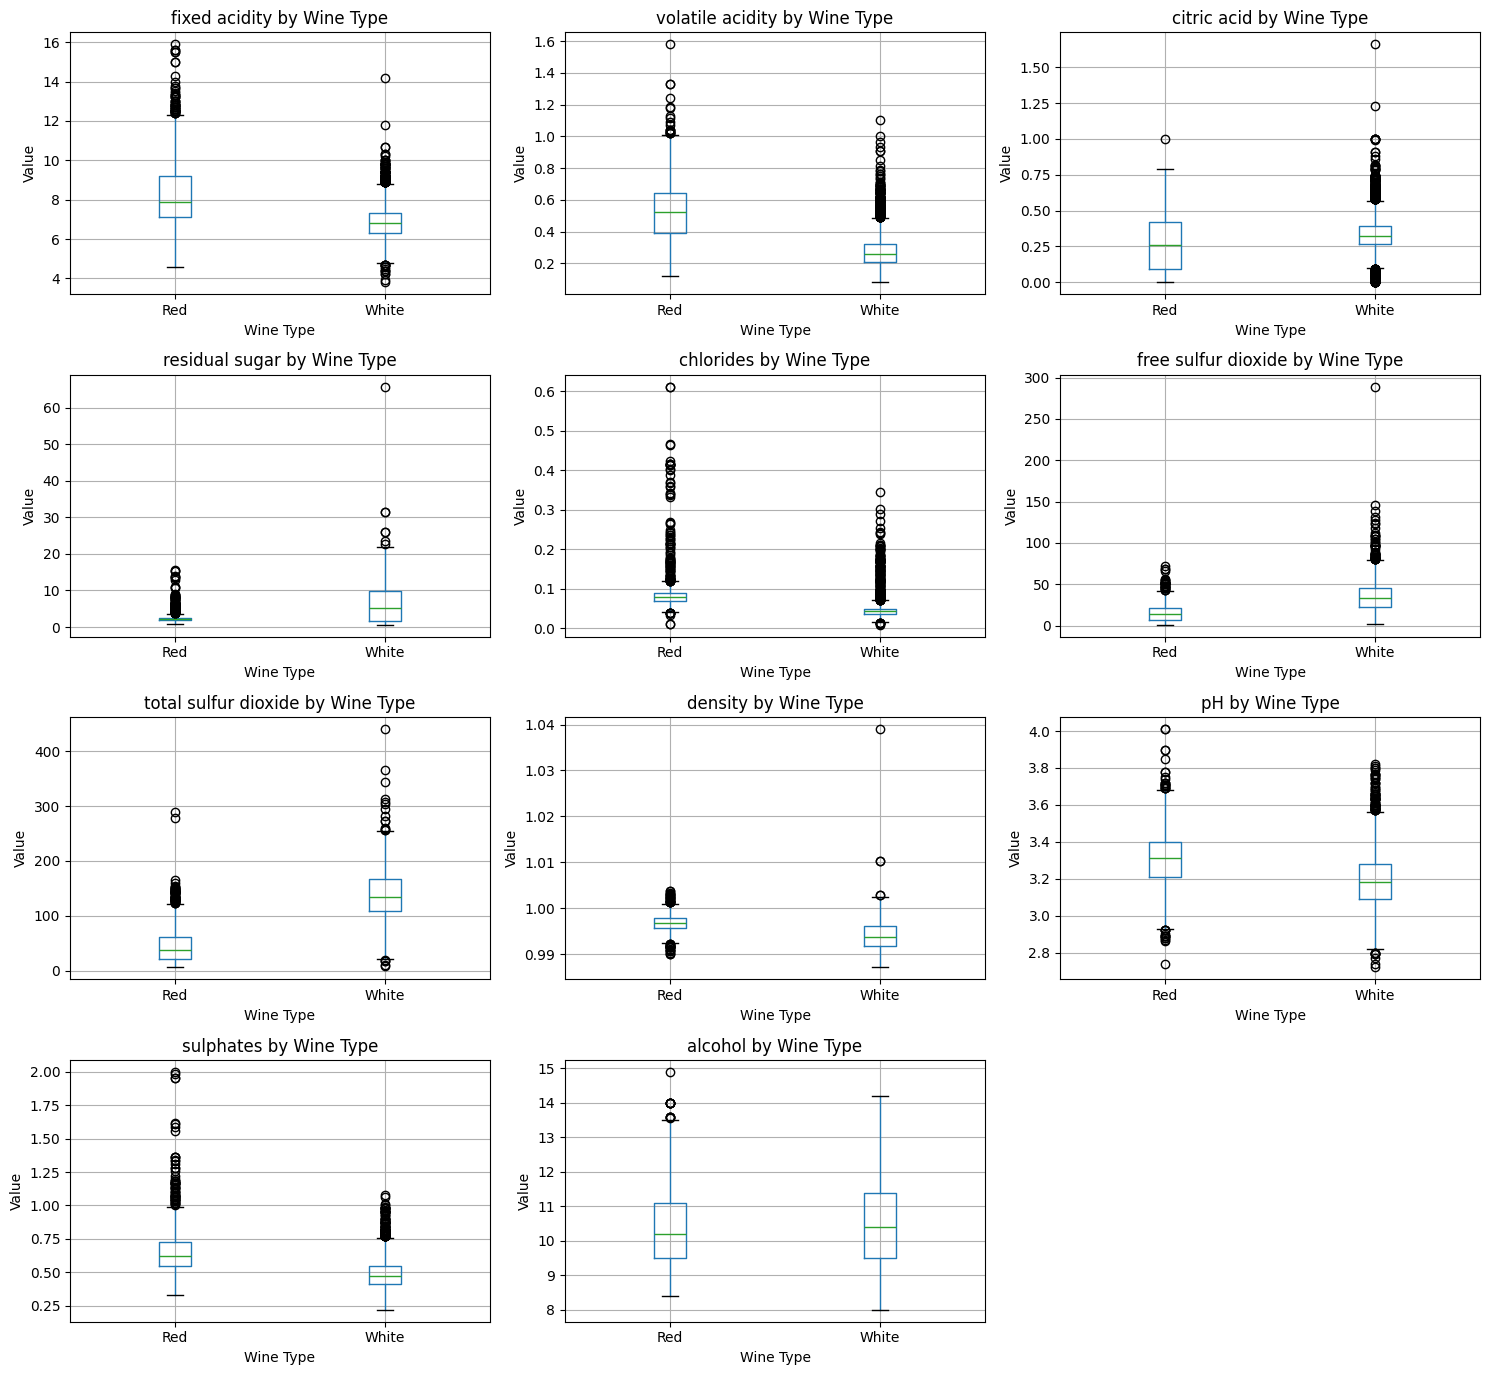

In [8]:
fig, axes = plt.subplots(4, 3, figsize=(15, 14))
axes = axes.ravel()

for idx, feature in enumerate(features):
    df.boxplot(column=feature, by='type', ax=axes[idx])
    axes[idx].set_title(f'{feature} by Wine Type')
    axes[idx].set_xlabel('Wine Type')
    axes[idx].set_ylabel('Value')
    plt.sca(axes[idx])
    plt.xticks([1, 2], ['Red', 'White'])

axes[-1].remove()
plt.suptitle('')
plt.tight_layout()
plt.show()

## Correlation Analysis

### Matriks Korelasi
Analisis korelasi Pearson antar fitur untuk mengidentifikasi hubungan linear antar variabel. Nilai korelasi berkisar dari -1 (korelasi negatif sempurna) hingga 1 (korelasi positif sempurna).

In [9]:
numeric_cols = df.select_dtypes(include=[np.number]).columns
correlation_matrix = df[numeric_cols].corr()

print('Correlation Matrix:')
print(correlation_matrix.round(3))

Correlation Matrix:
                      fixed acidity  volatile acidity  citric acid  \
fixed acidity                 1.000             0.219        0.324   
volatile acidity              0.219             1.000       -0.378   
citric acid                   0.324            -0.378        1.000   
residual sugar               -0.112            -0.196        0.142   
chlorides                     0.298             0.377        0.039   
free sulfur dioxide          -0.283            -0.353        0.133   
total sulfur dioxide         -0.329            -0.414        0.195   
density                       0.459             0.271        0.096   
pH                           -0.253             0.261       -0.330   
sulphates                     0.300             0.226        0.056   
alcohol                      -0.095            -0.038       -0.010   
quality                      -0.077            -0.266        0.086   

                      residual sugar  chlorides  free sulfur dioxide 

### Heatmap Korelasi

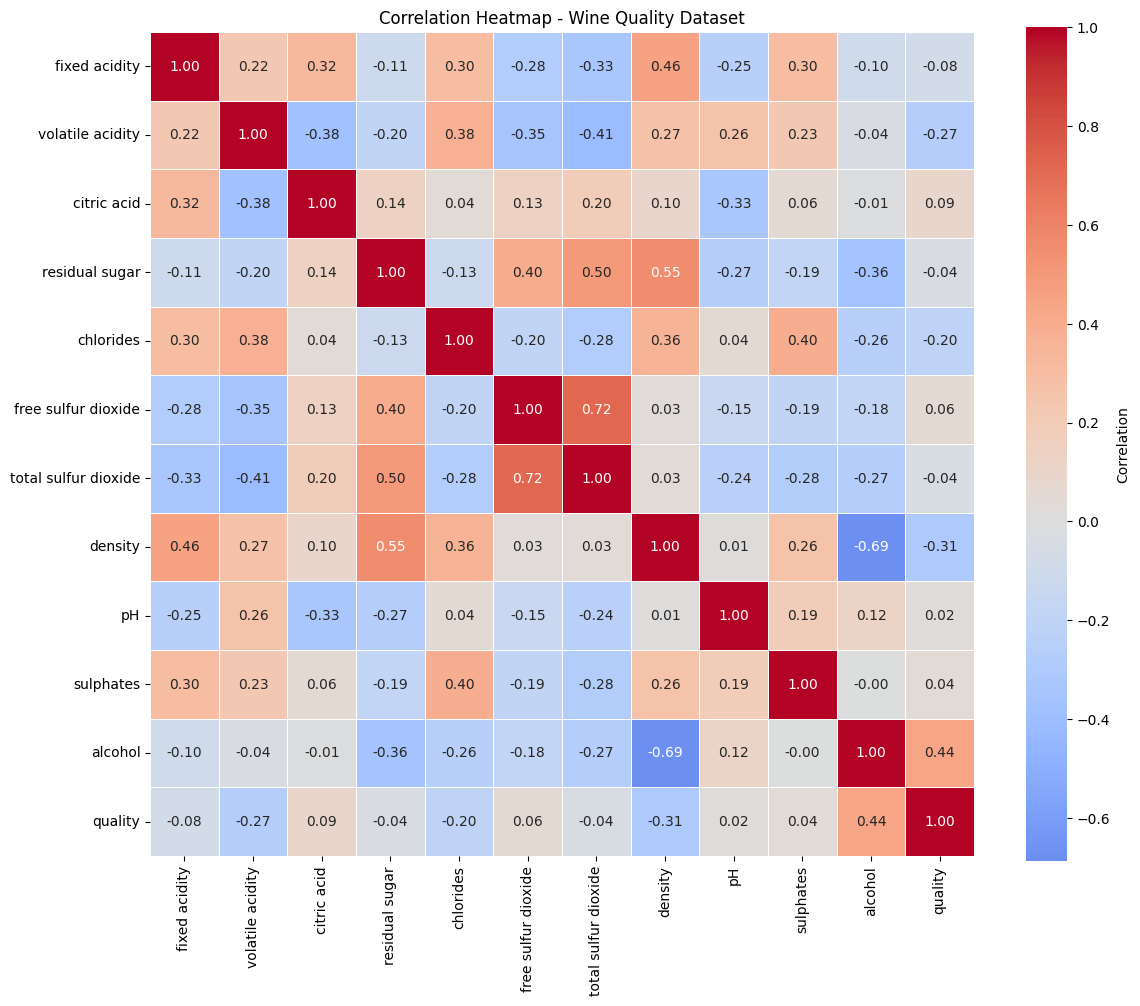

In [ ]:
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0, 
            square=True, linewidths=0.5, cbar_kws={'label': 'Correlation'})
plt.title('Correlation Heatmap - Wine Quality Dataset')
plt.tight_layout()
plt.show()

### Korelasi dengan Target Variable (Quality)
Menampilkan fitur-fitur yang memiliki korelasi tertinggi dengan skor kualitas wine.

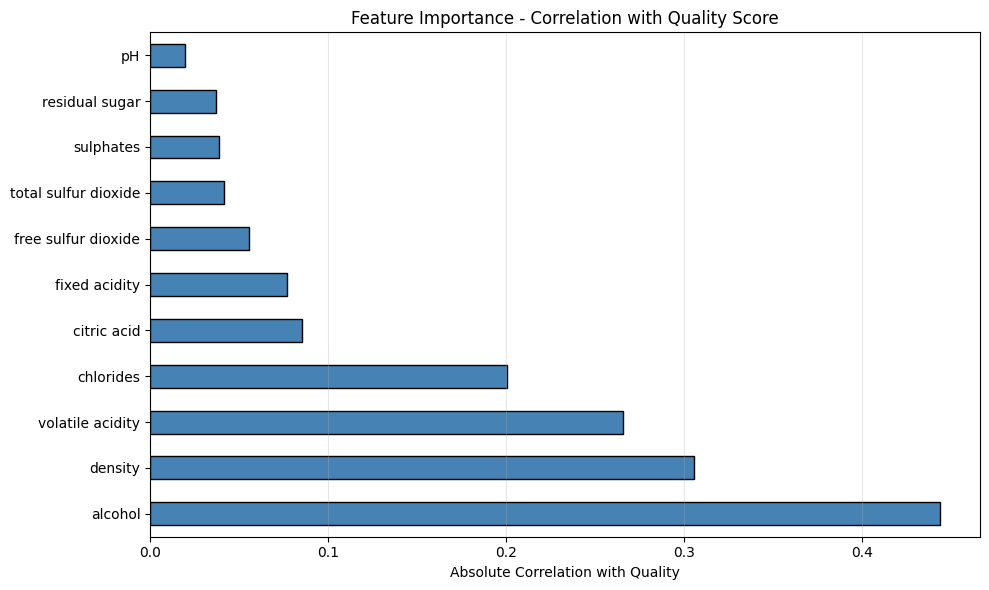

Feature Correlation with Quality (Sorted):
alcohol                   : 0.4443
density                   : 0.3059
volatile acidity          : 0.2657
chlorides                 : 0.2007
citric acid               : 0.0855
fixed acidity             : 0.0767
free sulfur dioxide       : 0.0555
total sulfur dioxide      : 0.0414
sulphates                 : 0.0385
residual sugar            : 0.0370
pH                        : 0.0195


In [ ]:
quality_correlation = correlation_matrix['quality'].drop('quality').abs().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 6))
quality_correlation.plot(kind='barh', ax=ax, color='steelblue', edgecolor='black')
ax.set_xlabel('Absolute Correlation with Quality')
ax.set_title('Feature Importance - Correlation with Quality Score')
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

print('Feature Correlation with Quality (Sorted):')
print('='*50)
for feature, corr in quality_correlation.items():
    print(f'{feature:25} : {corr:.4f}')

## Outlier Detection and Analysis

### Identifikasi Outlier Menggunakan Interquartile Range (IQR)

In [10]:
def count_outliers_iqr(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = data[(data[column] < lower_bound) | (data[column] > upper_bound)]
    return len(outliers), lower_bound, upper_bound

print('Outlier Analysis (IQR Method)')
print('='*70)

outlier_summary = {}
for feature in features:
    count, lower, upper = count_outliers_iqr(df, feature)
    outlier_summary[feature] = count
    percentage = (count / len(df)) * 100
    print(f'{feature:25} : {count:6} outliers ({percentage:5.2f}%)')

print('\n' + '='*70)
total_outlier_records = len(df[df.apply(lambda row: any(
    count_outliers_iqr(df, col)[0] > 0 for col in features
), axis=1)])
print(f'Total records with at least one outlier: {total_outlier_records}')

Outlier Analysis (IQR Method)
fixed acidity             :    357 outliers ( 5.49%)
volatile acidity          :    377 outliers ( 5.80%)
citric acid               :    509 outliers ( 7.83%)
residual sugar            :    118 outliers ( 1.82%)
chlorides                 :    286 outliers ( 4.40%)
free sulfur dioxide       :     62 outliers ( 0.95%)
total sulfur dioxide      :     10 outliers ( 0.15%)
density                   :      3 outliers ( 0.05%)
pH                        :     73 outliers ( 1.12%)
sulphates                 :    191 outliers ( 2.94%)
alcohol                   :      3 outliers ( 0.05%)

Total records with at least one outlier: 6497
